In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("./archive/UrbanSound8K.csv")
df.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [2]:
import librosa
import resampy
# First restart kernel 
print("Librosa version:", librosa.__version__)
print("Resampy version:", resampy.__version__)

Librosa version: 0.10.2.post1
Resampy version: 0.4.3


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import warnings
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load metadata
metadata_path = "./archive/UrbanSound8K.csv"
metadata = pd.read_csv(metadata_path)

# Function to extract MFCC and SSRP features
def extract_features(file_path, n_mfcc=40, n_ssrp=40):
    try:
        # Load audio file using librosa
        y, sr = librosa.load(file_path, sr=None, res_type='kaiser_fast')
        
        # Resample to a higher sampling rate if necessary
        if sr < 22050:
            y = librosa.resample(y, orig_sr=sr, target_sr=22050)
            sr = 22050
    except Exception as e:
        warnings.warn(f"Error loading {file_path}: {e}")
        return None  # Skip this file
    
    # Extract MFCC features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc = np.mean(mfcc.T, axis=0)
    
    # Extract SSRP features (custom implementation)
    stft = np.abs(librosa.stft(y))
    ssrp = librosa.feature.melspectrogram(S=stft, sr=sr, n_mels=n_ssrp, fmax=sr/2.0)
    ssrp = np.mean(ssrp.T, axis=0)
    
    # Combine MFCC and SSRP features
    features = np.hstack((mfcc, ssrp))
    return features

# Extract features and labels
features = []
labels = []
for index, row in metadata.iterrows():
    file_path = os.path.join("./archive", "fold" + str(row["fold"]), row["slice_file_name"])
    class_id = row["classID"]
    
    # Extract features
    feature = extract_features(file_path)
    if feature is not None:  # Skip files that couldn't be loaded
        features.append(feature)
        labels.append(class_id)

# Convert to numpy arrays
X = np.array(features)
y = to_categorical(labels)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

C:\Users\gargk\AppData\Roaming\Python\Python312\site-packages\librosa\feature\spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from sklearn.decomposition import PCA
import numpy as np

# Apply PCA for feature reduction
n_components = 40  # Choose an appropriate number based on explained variance
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Reshape data for CNN input
X_train_pca = X_train_pca.reshape(X_train_pca.shape[0], X_train_pca.shape[1], 1)
X_test_pca = X_test_pca.reshape(X_test_pca.shape[0], X_test_pca.shape[1], 1)

# Model architecture
model = Sequential()

# 1D CNN layers with Batch Normalization
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_components, 1)))
model.add(BatchNormalization())  # Added
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())  # Added
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())  # Added
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# Bi-LSTM layers
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))

# Fully connected layers with Batch Normalization
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())  # Added
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))  # 10 classes for UrbanSound8K

# Compile the model with AdamW optimizer and weight decay
optimizer = AdamW(learning_rate=0.001, weight_decay=1e-4)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()


C:\Users\gargk\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 38, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 17, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 6, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 3, 256)         │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,066 (2.64 MB)

 Trainable params: 692,042 (2.64 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.1866 - loss: 2.5185 - val_accuracy: 0.3930 - val_loss: 1.9404 - learning_rate: 0.0010
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.3620 - loss: 1.8528 - val_accuracy: 0.5261 - val_loss: 1.4029 - learning_rate: 0.0010
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.4290 - loss: 1.6476 - val_accuracy: 0.6356 - val_loss: 1.1450 - learning_rate: 0.0010
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.5304 - loss: 1.3854 - val_accuracy: 0.6571 - val_loss: 1.0151 - learning_rate: 0.0010
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.5858 - loss: 1.2393 - val_accuracy: 0.7301 - val_loss: 0.8844 - learning_rate: 0.0010
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.6351 - loss: 1.0801 - val_accuracy: 0.7595 - val_loss: 0.7513 - learning_rate: 0.0010
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.6

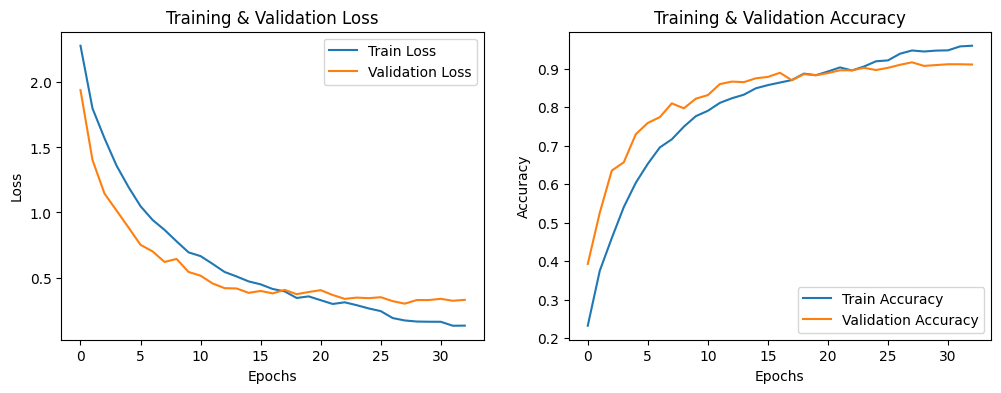

55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       203
           1       0.95      0.87      0.91        86
           2       0.82      0.93      0.87       183
           3       0.92      0.87      0.89       201
           4       0.97      0.86      0.91       206
           5       0.95      0.99      0.97       193
           6       0.94      0.83      0.88        72
           7       0.92      0.99      0.95       208
           8       0.95      0.96      0.95       165
           9       0.86      0.84      0.85       230

    accuracy                           0.92      1747
   macro avg       0.92      0.91      0.91      1747
weighted avg       0.92      0.92      0.92      1747

Final Test Accuracy: 0.9164


In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Learning rate scheduler to dynamically adjust learning rate
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-5)

# Train the model
history = model.fit(
    X_train_pca, y_train,
    epochs=100, batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stopping, lr_scheduler]
)

# Plot training loss and accuracy
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training & Validation Loss')

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training & Validation Accuracy')

    plt.show()

# Call the function to plot training history
plot_training_history(history)

# Evaluate on the test set
y_pred = model.predict(X_test_pca)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert predictions to class indices
y_true = np.argmax(y_test, axis=1)  # Convert one-hot labels to class indices

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))

# Print final test accuracy
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"Final Test Accuracy: {test_accuracy:.4f}")
